# Find outliers

### Import packages

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import csv
import numpy as np
import os
import requests
from io import StringIO
from sklearn.cluster import KMeans
from matplotlib.ticker import MaxNLocator
import seaborn as sns

### Import dataset

In [3]:
df_dataset = pd.read_csv('../dataset/behavioural_data/experiment_trials.csv')

#### Outlier detection

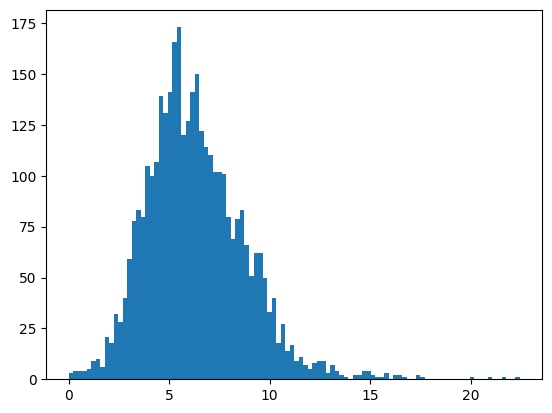

In [4]:
plt.hist(df_dataset["ReproducedTime"], bins=100)
plt.show()

In [5]:
df_experiment_clean_filtered_list = []

for (participant_id, gamble_deadline), df_group in df_dataset.groupby(
    ["ParticipantID", "GambleDeadline"]
):
    df_group = df_group.copy()

    # log-transform: only valid if all values are > 0
    rt = df_group["ReproducedTime"]

    median_rt = rt.median()
    mad_rt = 1.4826 * (rt - median_rt).abs().median()

    if mad_rt == 0:
        df_experiment_clean_filtered_list.append(df_group)
        continue

    threshold = 3  # paper's preferred default
    keep = ((rt - median_rt).abs() / mad_rt) <= threshold

    df_experiment_clean_filtered_list.append(df_group.loc[keep])

df_experiment_clean_filtered = pd.concat(
    df_experiment_clean_filtered_list,
    ignore_index=True
)

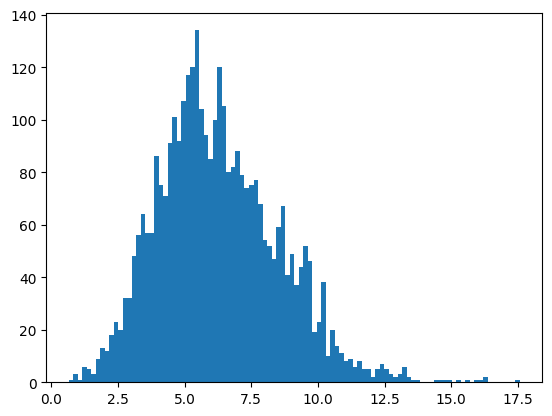

In [6]:
plt.hist(df_experiment_clean_filtered["ReproducedTime"], bins=100)
plt.show()

In [7]:
print(1- len(df_experiment_clean_filtered)/len(df_dataset))

0.03758351893095768


#### Save to CSV file

In [8]:
df_experiment_clean_filtered.to_csv("../dataset/behavioural_data/processed_experiment_data.csv", index=False)
